# 13_get_sequence_encodings

Run sequence encoding generation using `agentic_protein_design.steps.get_sequence_encodings`.
This notebook reflects the current step API (`root_key`, `data_subfolder`, `encodings_subfolder`).

## Python Path Setup

In [1]:
from pathlib import Path
import sys

# Section 1: Resolve repo root from either project root or notebooks/ cwd.
cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == "notebooks" else cwd

# Section 2: Add repo and src roots to sys.path for imports.
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
src_root = repo_root / "src"
if src_root.exists() and str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

print("repo_root:", repo_root)
print("src_root:", src_root)


repo_root: /Users/charmainechia/Documents/projects/agentic-protein-design
src_root: /Users/charmainechia/Documents/projects/agentic-protein-design/src


## Imports

In [2]:
import importlib
from pathlib import Path

import numpy as np
import pandas as pd

import agentic_protein_design.steps.get_sequence_encodings as enc_step
enc_step = importlib.reload(enc_step)

default_user_inputs = enc_step.default_user_inputs
parse_sequence_input = enc_step.parse_sequence_input
split_feature_sets = enc_step.split_feature_sets
get_sequence_encodings = enc_step.get_sequence_encodings


## User Inputs

In [7]:
user_inputs = default_user_inputs()

# Section 1: Configure output root and subfolders.
user_inputs["root_key"] = "examples"
user_inputs["data_subfolder"] = "ET096_R1-2"
user_inputs["encodings_subfolder"] = "encodings/"

# Section 2: Configure sequence input source.
# Use an absolute path for notebook portability.
# user_inputs["sequence_input"] = None
user_inputs["sequence_input"] = str(
    repo_root / "examples" / "expdata" / user_inputs["data_subfolder"] / "ET096_R1-2.csv"
)

# Section 3: Configure column names and optional base sequence fallback.
user_inputs["sequence_col"] = "sequence"
user_inputs["sequence_base_col"] = "sequence_base"
user_inputs["mutation_col"] = "mutations"
user_inputs["sequence_base"] = None
# user_inputs["sequence_base"] = 'MKLTLLLSAVFSGAVATLAETSEWSPPESGDARSPCPLLNSLANHGYLPHDGKNITGDVLSKAITTTLNMDDSVSAAFMAALRNSITTAETFSLDELNKHNGIEHDASLSRQDFYFGNVQAFNETIFNQTRSYWTDPVTIDIHQAANARNARIETSKATNPTYNETAVNRASALETAAYILSFGDKVTGSVPKAFVEYFFENERLPFHLGWYKSAESISFADFQNMSTRVSQAGSQSPRAIEL'

# Section 4: Configure feature sets.
# Default: FEATURE_SETS_DEFAULT from project_config/feature_registry.py
# user_inputs["feature_sets"] = None
# Example explicit list:
user_inputs["feature_sets"] = [
    "one_hot",
    "georgiev",
    "esm2-650m_LLR",
    # "esm2-650m_per_residue",
    "esm2-650m_mean_pooled",
    "esmc-600m_LLR",
    # "esmc-600m_per_residue",
    "esmc-600m_mean_pooled",
]

# Section 5: Optional runtime controls.
user_inputs["get_embeddings_for_seq_base"] = False
user_inputs["classical_max_length"] = None
user_inputs["marginal_type"] = 'masked' # "wt" #
user_inputs["mutations_sep"] = "+"
user_inputs["layers"] = {'esm2-650m': [33], 'esmc-600m': [36]}
user_inputs["batch_size"] = 4
user_inputs["device"] = None
user_inputs["save_per_residue_embeddings"] = True

user_inputs


{'root_key': 'examples',
 'data_subfolder': 'ET096_R1-2',
 'encodings_subfolder': 'encodings/',
 'sequence_input': '/Users/charmainechia/Documents/projects/agentic-protein-design/examples/expdata/ET096_R1-2/ET096_R1-2.csv',
 'sequence_col': 'sequence',
 'sequence_base_col': 'sequence_base',
 'mutation_col': 'mutations',
 'sequence_base': None,
 'feature_sets': ['one_hot',
  'georgiev',
  'esm2-650m_LLR',
  'esm2-650m_mean_pooled',
  'esmc-600m_LLR',
  'esmc-600m_mean_pooled'],
 'get_embeddings_for_seq_base': False,
 'classical_max_length': None,
 'marginal_type': 'masked',
 'mutations_sep': '+',
 'layers': {'esm2-650m': [33], 'esmc-600m': [36]},
 'batch_size': 4,
 'device': None,
 'save_per_residue_embeddings': True}

## Run Step

Obtaining one_hot encodings...
Obtaining georgiev encodings...
Obtaining zero-shot scores for esm2-650m...
Device: cpu
[zeroshot/masked-marginal] Saved raw scores: /Users/charmainechia/Documents/projects/agentic-protein-design/examples/encodings/ET096_R1-2/esm2-650m_LLR-masked.csv


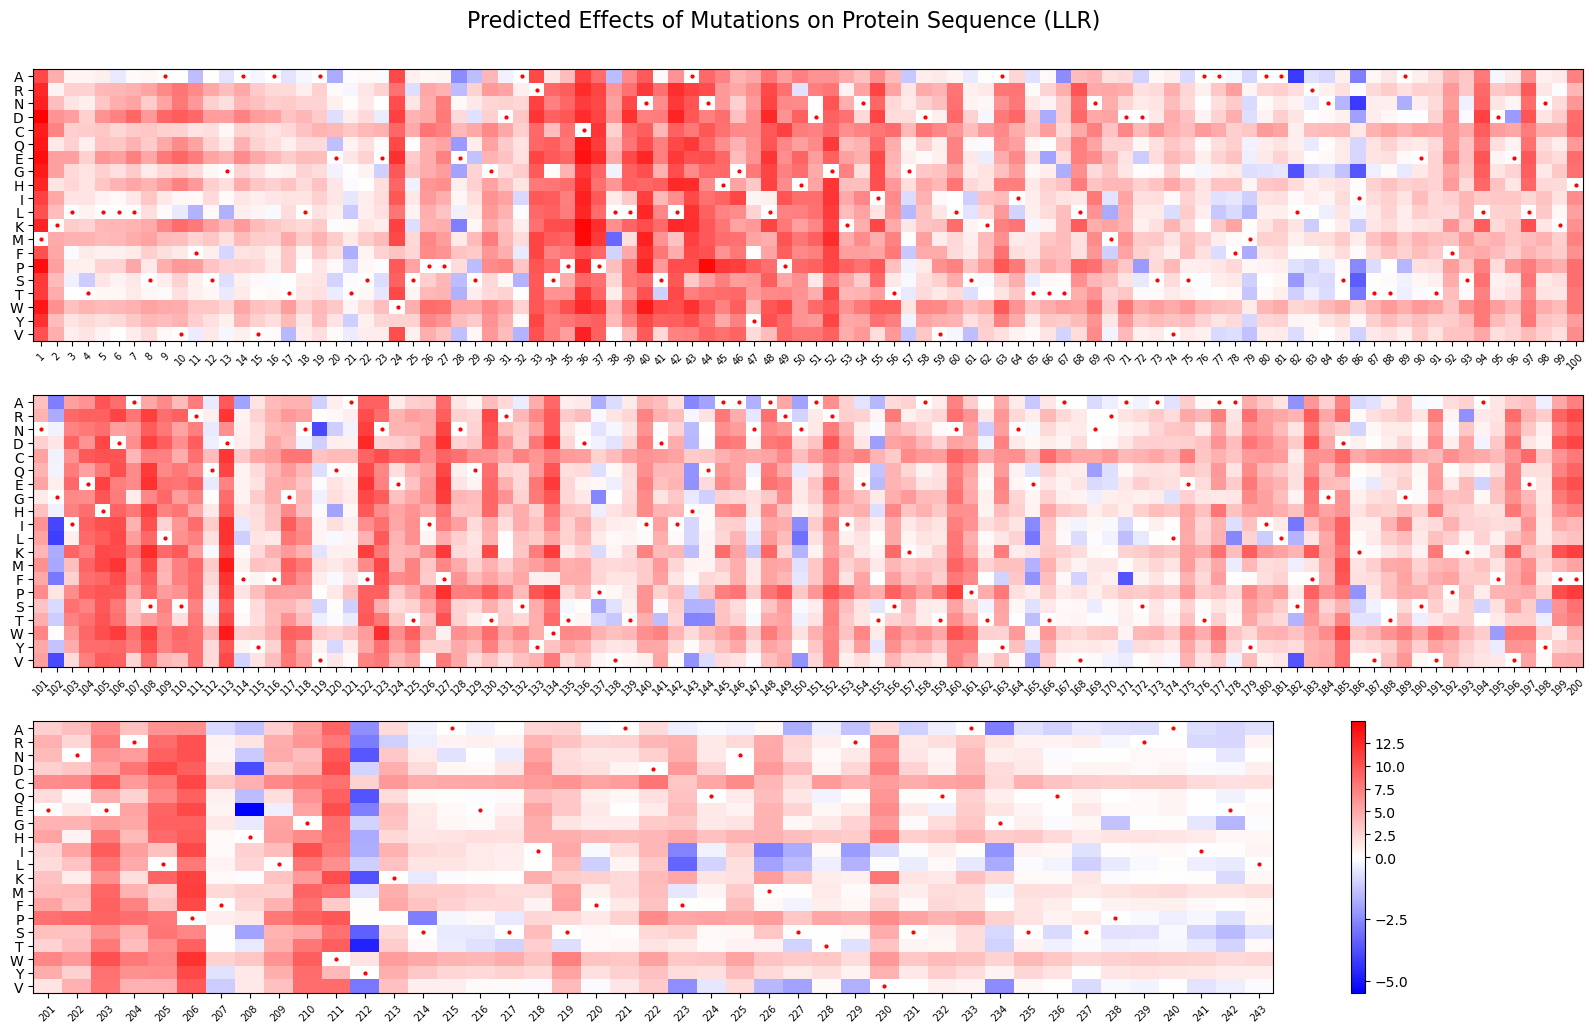

Obtaining embeddings for esm2-650m...
Device: cpu
[get_embeddings] Saved per_residue layer 33: /Users/charmainechia/Documents/projects/agentic-protein-design/examples/encodings/ET096_R1-2/esm2-650m_per_residue-33.npy
[get_plm_encodings] Saved mean_pooled layer 33: /Users/charmainechia/Documents/projects/agentic-protein-design/examples/encodings/ET096_R1-2/esm2-650m_mean_pooled-33.npy
Obtaining zero-shot scores for esmc-600m...
Device: cpu
[zeroshot/masked-marginal] Saved raw scores: /Users/charmainechia/Documents/projects/agentic-protein-design/examples/encodings/ET096_R1-2/esmc-600m_LLR-masked.csv


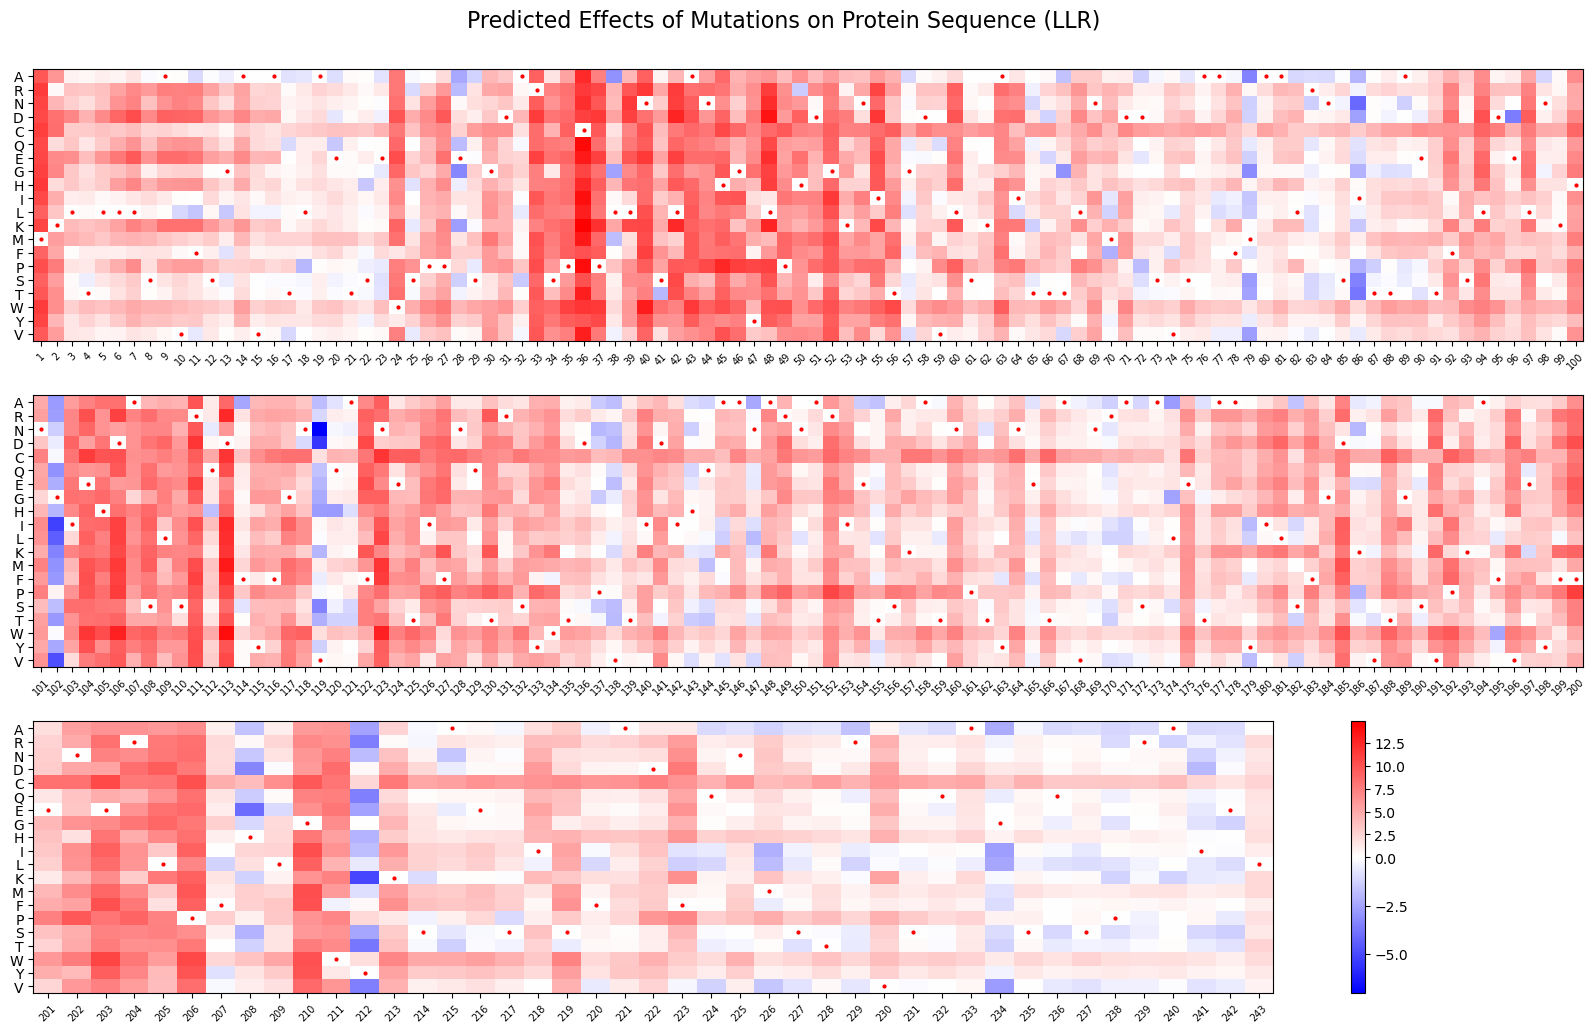

Obtaining embeddings for esmc-600m...
Device: cpu
[get_embeddings] Saved per_residue layer 36: /Users/charmainechia/Documents/projects/agentic-protein-design/examples/encodings/ET096_R1-2/esmc-600m_per_residue-36.npy
[get_plm_encodings] Saved mean_pooled layer 36: /Users/charmainechia/Documents/projects/agentic-protein-design/examples/encodings/ET096_R1-2/esmc-600m_mean_pooled-36.npy
status: ok
encodings_dir: /Users/charmainechia/Documents/projects/agentic-protein-design/examples/encodings/ET096_R1-2
n_classical_features: 2
n_plm_features: 4
classical result keys: ['georgiev', 'one_hot']
plm result keys: ['esm2-650m_LLR', 'esm2-650m_mean_pooled', 'esmc-600m_LLR', 'esmc-600m_mean_pooled']


In [8]:
# Section 1: Execute sequence encoding workflow.
result = get_sequence_encodings(user_inputs)

# Section 2: Print concise run summary.
print("status:", result.get("status", ""))
print("encodings_dir:", result.get("encodings_dir", ""))
print("n_classical_features:", len(result.get("feature_sets", {}).get("classical", [])))
print("n_plm_features:", len(result.get("feature_sets", {}).get("plm", [])))
print("classical result keys:", sorted(result.get("classical_results", {}).keys()))
print("plm result keys:", sorted(result.get("plm_results", {}).keys()))


## Inspect Saved Artifacts

In [ ]:
enc_dir = Path(result["encodings_dir"])

# Section 1: List saved files in encodings directory.
all_files = sorted([p for p in enc_dir.glob("*") if p.is_file()])
print("encodings_dir:", enc_dir)
print("n_files:", len(all_files))
for p in all_files:
    print("-", p.name)

# Section 2: Build a compact table of key outputs from run metadata.
rows = []
for name, info in result.get("classical_results", {}).items():
    rows.append({
        "feature": name,
        "kind": "classical",
        "primary_path": info.get("seq_encoding_path"),
        "base_path": info.get("seq_base_encoding_path"),
    })
for name, info in result.get("plm_results", {}).items():
    rows.append({
        "feature": name,
        "kind": "plm",
        "primary_path": info.get("output_path") or str(info.get("artifacts", {})),
        "base_path": None,
    })

pd.DataFrame(rows)


## Optional: Quick Load Check

In [ ]:
# Section 1: Try loading a few known artifacts if present.
enc_dir = Path(result["encodings_dir"])

candidates = [
    enc_dir / "one_hot.npz",
    enc_dir / "georgiev.npy",
]

for f in candidates:
    if not f.exists():
        continue
    if f.suffix == ".npz":
        from scipy import sparse
        m = sparse.load_npz(str(f))
        print(f"{f.name}: sparse shape={m.shape}, nnz={m.nnz}")
    else:
        arr = np.load(str(f), allow_pickle=True)
        print(f"{f.name}: shape={arr.shape}, dtype={arr.dtype}")
